In [ ]:
import pandas as pd
import plotly.graph_objects as go
df = pd.read_csv("../data/processed/clean_nav.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
fig = go.Figure()
for code in df["amfi_code"].unique():
    temp = df[df["amfi_code"] == code]
    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["nav"],
            mode="lines",
            name=f"Scheme {code}",
            opacity=0.5
        )
    )
# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)
# Highlight 2024 Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)
fig.update_layout(
    title="NAV Trend Analysis (2022–2026) - 40 Mutual Fund Schemes",
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    hovermode="x unified",
    legend_title="AMFI Schemes",
    height=750
)

fig.show()

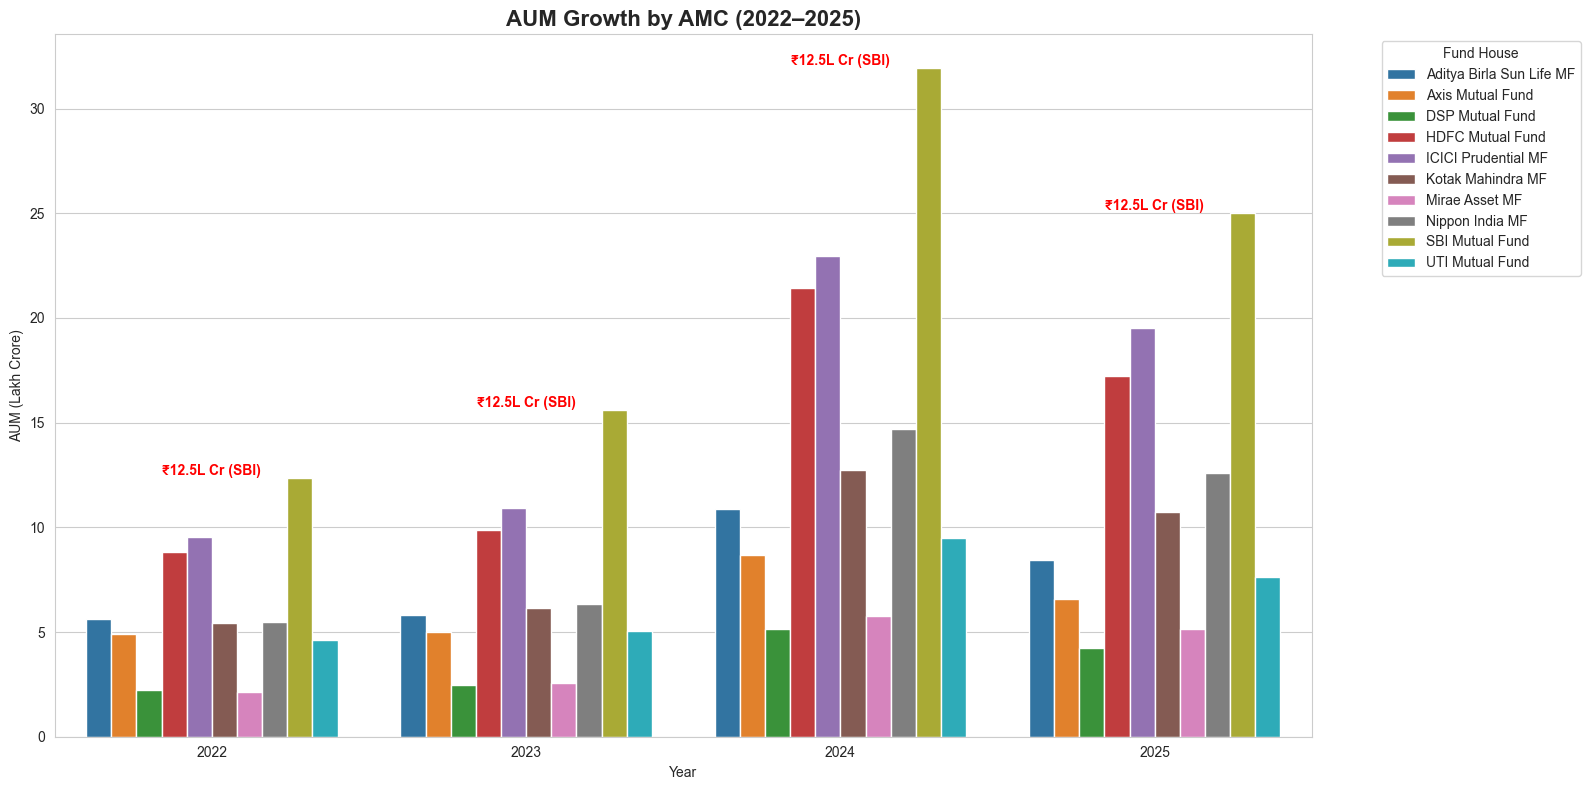

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df = df[df['year'].between(2022, 2025)]
aum_df = df.groupby(['year', 'fund_house'], as_index=False)['aum_lakh_crore'].sum()
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=aum_df,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        label = bar.get_label() if hasattr(bar, "get_label") else None
sbi_df = aum_df[aum_df['fund_house'].str.upper() == "SBI MUTUAL FUND"]
for _, row in sbi_df.iterrows():
    plt.text(
        x=list(sorted(aum_df['year'].unique())).index(row['year']),
        y=row['aum_lakh_crore'],
        s="₹12.5L Cr (SBI)",
        ha='center',
        va='bottom',
        fontsize=10,
        color='red',
        fontweight='bold'
    )
plt.title("AUM Growth by AMC (2022–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month")
fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    title="SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)
# Highlight Dec 2025 milestone
milestone = df[df["month"] == "2025-12-01"]

if not milestone.empty:
    value = milestone["sip_inflow_crore"].iloc[0]

    fig.add_scatter(
        x=milestone["month"],
        y=milestone["sip_inflow_crore"],
        mode="markers+text",
        text=["₹31,002 Cr All-Time High"],
        textposition="top center",
        marker=dict(size=12, color="red"),
        name="Dec 2025 Milestone"
    )

    fig.add_annotation(
        x=milestone["month"].iloc[0],
        y=value,
        text=f"₹{value:,.0f} Cr",
        showarrow=True,
        arrowhead=2,
        yshift=20
    )
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    title_x=0.5
)
fig.show()

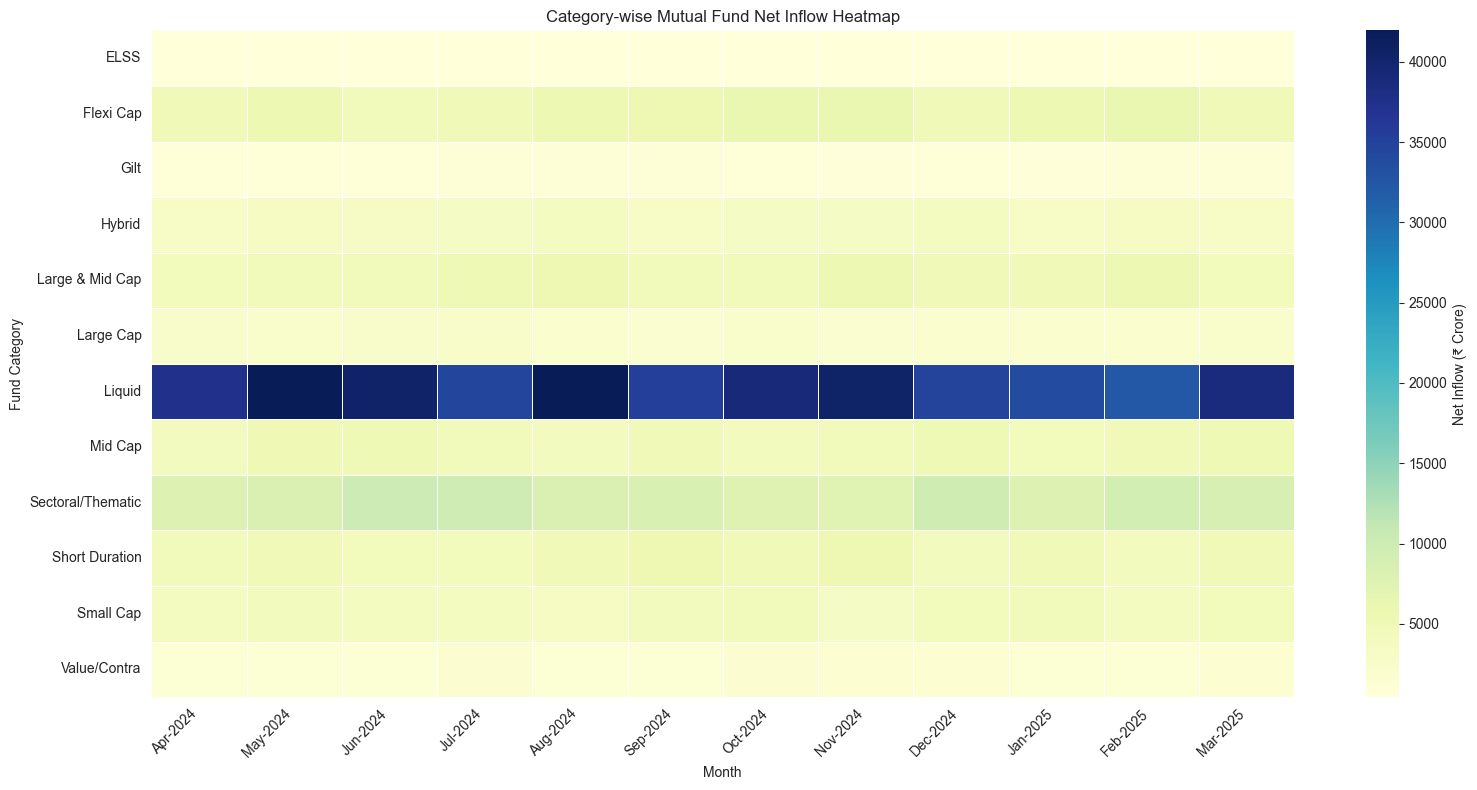

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/clean_category_inflows.csv")
df['month'] = pd.to_datetime(df['month'])
df['month_label'] = df['month'].dt.strftime('%b-%Y')
heatmap_data = df.pivot_table(
    index='category',
    columns='month_label',
    values='net_inflow_crore',
    aggfunc='sum'
)
month_order = (
    df[['month', 'month_label']]
    .drop_duplicates()
    .sort_values('month')
)['month_label']
heatmap_data = heatmap_data[month_order]
plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)
plt.title('Category-wise Mutual Fund Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

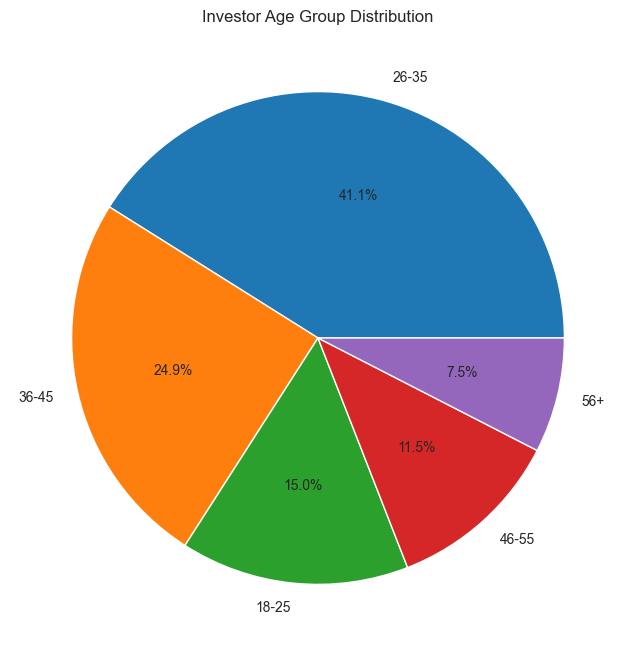

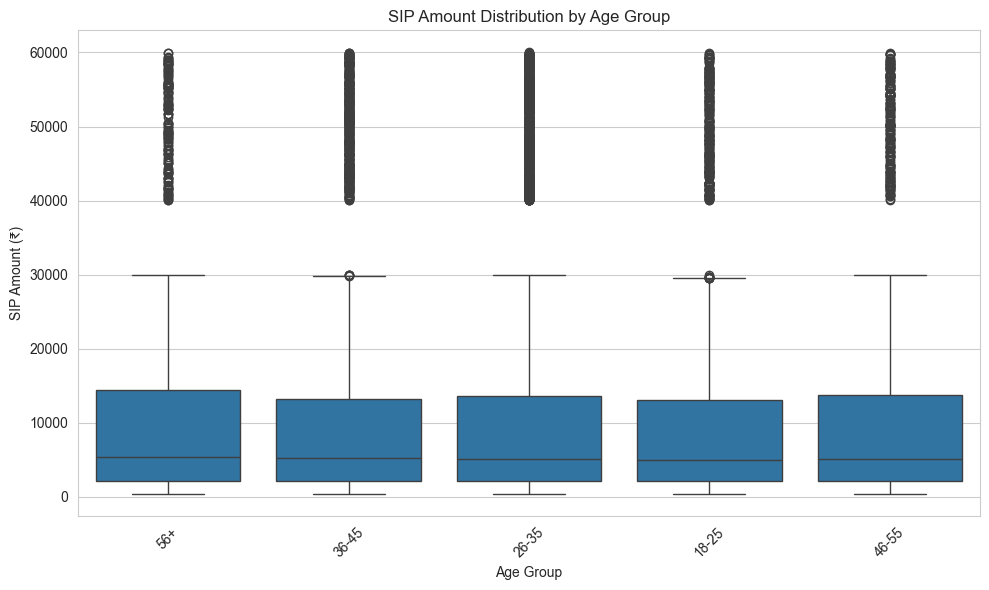

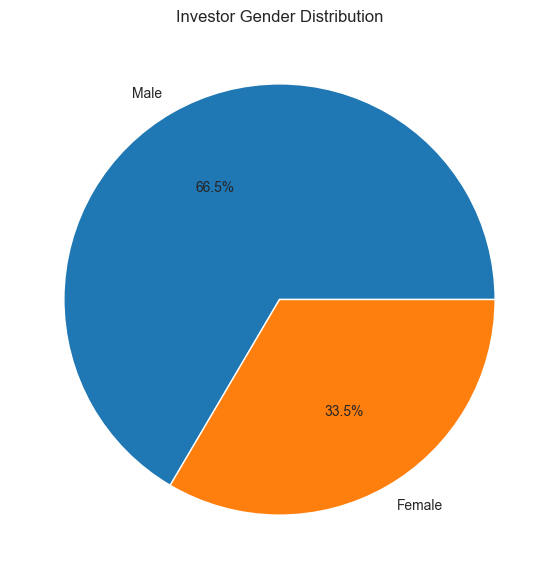

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/clean_transactions.csv")
# 1. Age Group Distribution Pie Chart
plt.figure(figsize=(8, 8))
df['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Investor Age Group Distribution')
plt.ylabel('')
plt.show()
# 2. SIP Amount Box Plot by Age Group
sip_df = df[df['transaction_type'] == 'SIP']
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sip_df,
    x='age_group',
    y='amount_inr'
)
plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# 3. Gender Split Chart
plt.figure(figsize=(7, 7))
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Investor Gender Distribution')
plt.ylabel('')
plt.show()

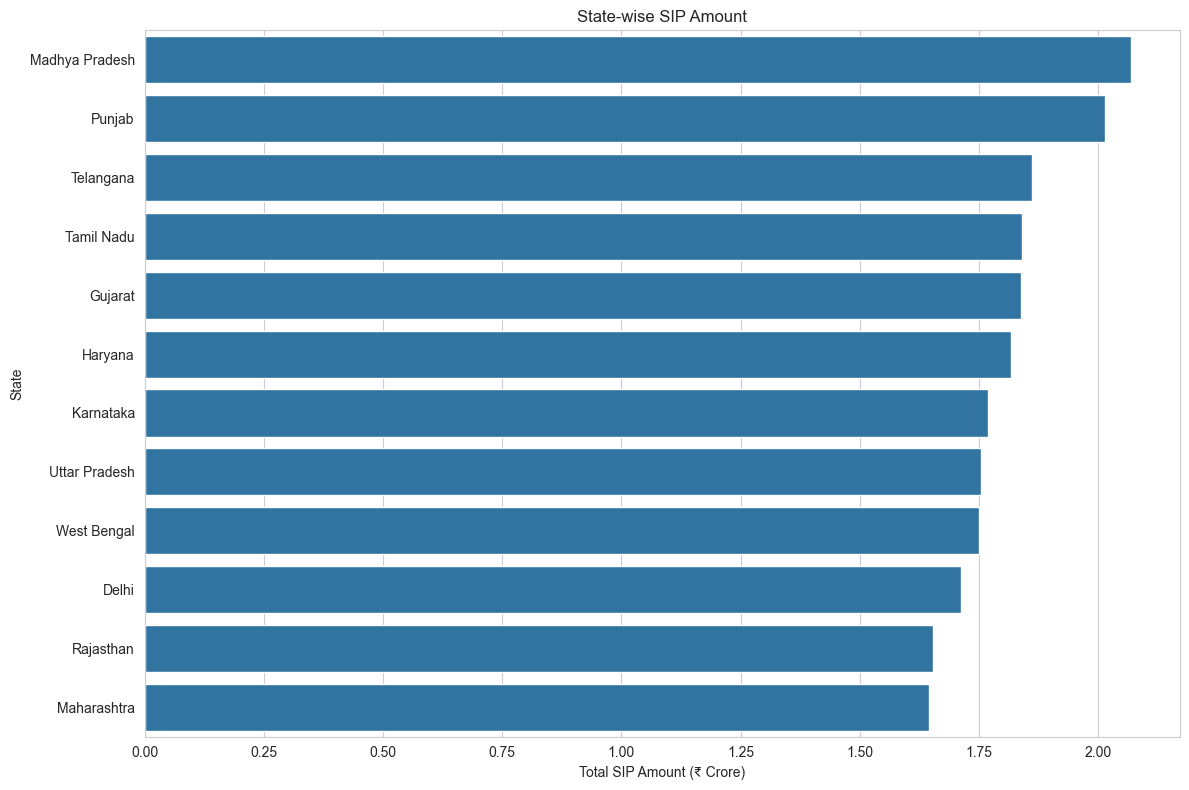

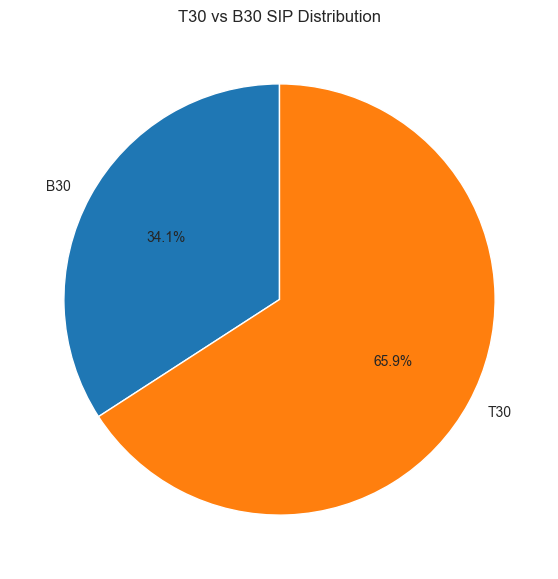

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/clean_transactions.csv")
# Filter SIP transactions if needed
sip_df = df[df['transaction_type'].str.upper() == 'SIP']

# State-wise SIP amount
state_sip = (
    sip_df.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
state_sip['amount_crore'] = state_sip['amount_inr'] / 10000000
plt.figure(figsize=(12, 8))
sns.barplot(
    data=state_sip,
    x='amount_crore',
    y='state'
)

plt.title('State-wise SIP Amount')
plt.xlabel('Total SIP Amount (₹ Crore)')
plt.ylabel('State')
plt.tight_layout()
plt.show()
#T30 vs B30 pie chart
tier_data = (
    df.groupby('city_tier')['amount_inr']
    .sum()
    .reset_index()
)

plt.figure(figsize=(7,7))
plt.pie(
    tier_data['amount_inr'],
    labels=tier_data['city_tier'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('T30 vs B30 SIP Distribution')
plt.show()

In [21]:
import pandas as pd
import plotly.express as px
df = pd.read_csv("../data/processed/clean_industry_folio_count.csv")
# Convert month column to datetime
df['month'] = pd.to_datetime(df['month'])

# Key milestones
start_idx = df['total_folios_crore'].idxmin()
end_idx = df['total_folios_crore'].idxmax()

fig = px.line(
    df,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Folio Count Growth (Jan 2022 - Dec 2025)',
    markers=True
)

# Starting milestone (13.26 Cr)
fig.add_annotation(
    x=df.loc[start_idx, 'month'],
    y=df.loc[start_idx, 'total_folios_crore'],
    text=f"Start: {df.loc[start_idx, 'total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Ending milestone (26.12 Cr)
fig.add_annotation(
    x=df.loc[end_idx, 'month'],
    y=df.loc[end_idx, 'total_folios_crore'],
    text=f"End: {df.loc[end_idx, 'total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# 15 Cr milestone
milestone_15 = df[df['total_folios_crore'] >= 15].head(1)
if not milestone_15.empty:
    fig.add_annotation(
        x=milestone_15['month'].iloc[0],
        y=milestone_15['total_folios_crore'].iloc[0],
        text='15 Cr',
        showarrow=True
    )

# 20 Cr milestone
milestone_20 = df[df['total_folios_crore'] >= 20].head(1)
if not milestone_20.empty:
    fig.add_annotation(
        x=milestone_20['month'].iloc[0],
        y=milestone_20['total_folios_crore'].iloc[0],
        text='20 Cr',
        showarrow=True
    )

# 25 Cr milestone
milestone_25 = df[df['total_folios_crore'] >= 25].head(1)
if not milestone_25.empty:
    fig.add_annotation(
        x=milestone_25['month'].iloc[0],
        y=milestone_25['total_folios_crore'].iloc[0],
        text='25 Cr',
        showarrow=True
    )

fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Folios (Crore)',
    hovermode='x unified'
)

fig.show()

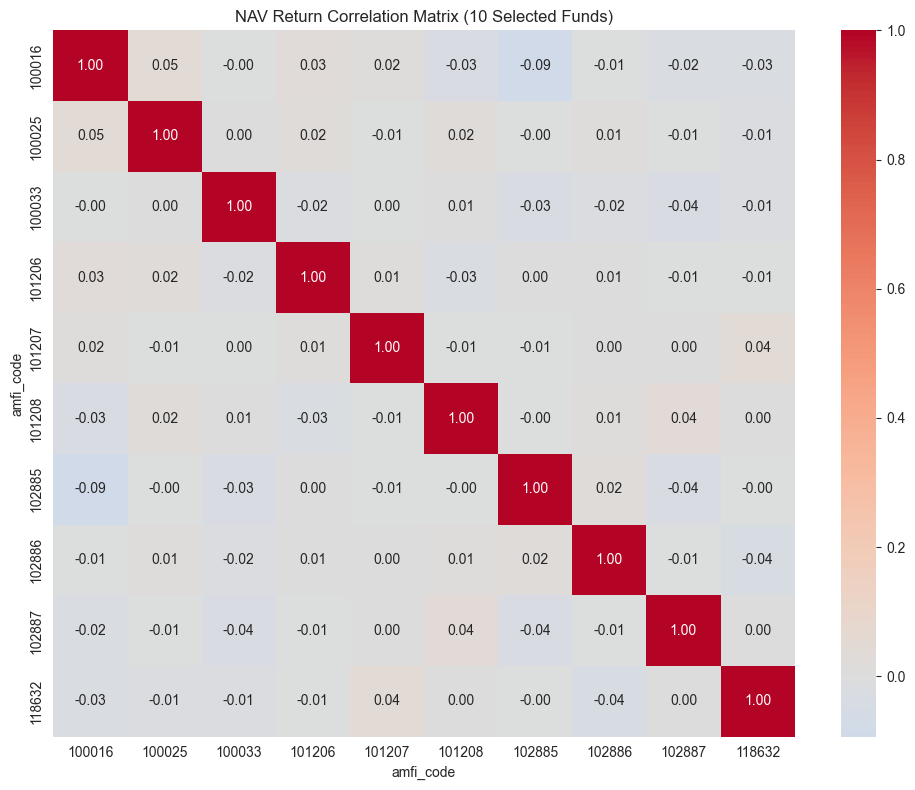

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/clean_nav.csv")
df["date"] = pd.to_datetime(df["date"])
selected_funds = df["amfi_code"].unique()[:10]
df = df[df["amfi_code"].isin(selected_funds)]
nav_pivot = df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = nav_pivot.pct_change().dropna()
corr_matrix = returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("NAV Return Correlation Matrix (10 Selected Funds)")
plt.tight_layout()
plt.show()

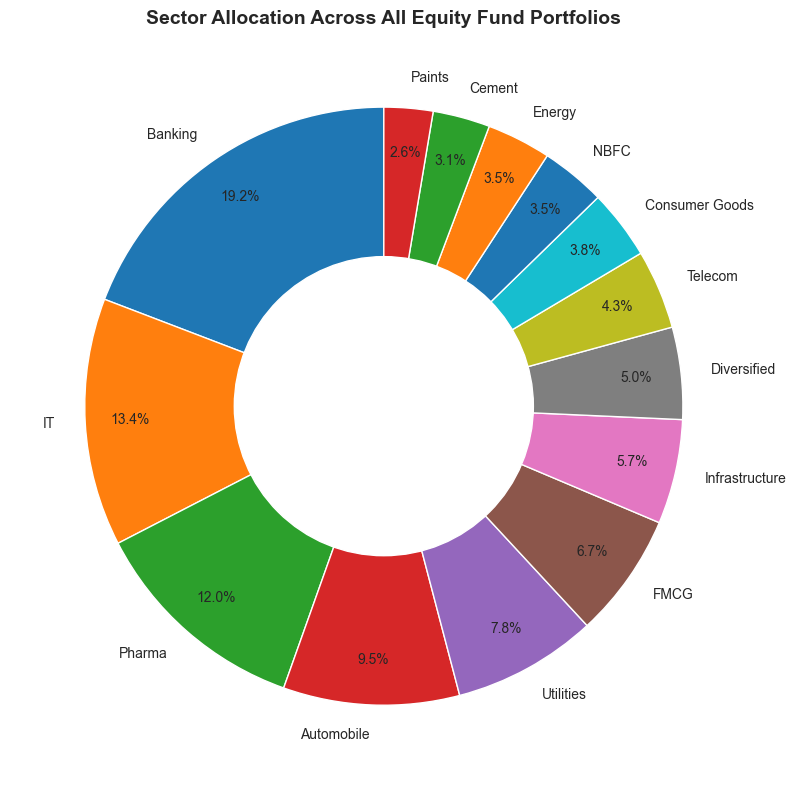

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
sector_weights = (
    df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title(
    "Sector Allocation Across All Equity Fund Portfolios",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Key EDA Findings

## 1. SIP Inflows Show Consistent Growth
Monthly SIP inflows increased steadily from 2022 to 2025, reaching an all-time high of ₹31,002 Cr in December 2025.
**Chart Reference:** SIP Inflow Trend (Plotly Line Chart)

---

## 2. Mutual Fund Folios Nearly Doubled
Total mutual fund folios grew from 13.26 Cr in January 2022 to 26.12 Cr by December 2025, indicating rapid retail participation.
**Chart Reference:** Folio Count Growth Chart

---

## 3. SBI Mutual Fund Leads Industry AUM
Among all fund houses, SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM).
**Chart Reference:** AUM Growth by AMC (Grouped Bar Chart)

---

## 4. Equity Funds Dominate Investor Preference
Equity-oriented schemes attracted the largest share of inflows compared to other fund categories.
**Chart Reference:** Category-wise Inflow Heatmap

---

## 5. Technology and Financial Services Are Top Portfolio Sectors
Aggregate portfolio holdings show significant allocation towards Technology and Financial sectors across equity schemes.
**Chart Reference:** Sector Allocation Donut Chart

---

## 6. Most Funds Moved Together During Market Trends
NAV return correlations reveal that many equity schemes exhibit strong positive relationships during market rallies and corrections.
**Chart Reference:** Correlation Matrix Heatmap

---

## 7. Significant NAV Growth During 2023 Bull Market
Most schemes experienced strong NAV appreciation throughout 2023, reflecting favorable market conditions.
**Chart Reference:** NAV Trend Analysis

---

## 8. Tamil Nadu, Gujarat, and Madhya Pradesh Contribute Strong SIP Volumes
Several states contribute disproportionately high SIP investments, indicating strong regional participation.
**Chart Reference:** SIP Geographic Distribution Bar Chart

---

## 9. Working-Age Investors Form the Largest Investor Segment
The majority of investors belong to middle-age groups, contributing the highest transaction volumes.
**Chart Reference:** Age Group Distribution Pie Chart

---

## 10. SIP Investment Amounts Vary Across Demographics
Box plot analysis shows noticeable variation in SIP contribution amounts among different age groups.
**Chart Reference:** SIP Amount by Age Group Box Plot